In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
df = sns.load_dataset('titanic')
target = 'survived'

In [ ]:
X = df.drop(columns=[target])
Y = df[target]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,random_state=42,test_size=0.2,stratify = Y)

In [ ]:
X_train['embark_town'].value_counts()

,count
embark_town,
Southampton,516
Cherbourg,139
Queenstown,55


In [ ]:
# remove redundant columns
X_train = X_train.drop(columns=['class','embark_town'])
X_test = X_test.drop(columns=['class','embark_town'])

In [ ]:
num_columns = X_train.select_dtypes(include = np.number).columns.tolist()
cat_columns = X_train.select_dtypes(exclude = np.number).columns.tolist()
num_columns


['pclass', 'age', 'sibsp', 'parch', 'fare']

In [ ]:
X_train['deck'] = X_train['deck'].fillna(X_train['deck'].mode()[0])

In [ ]:
# Split into binary, ordinal category & nominal categories
for col in cat_columns:
  print(col, X_train[col].unique())
  print("_"*50)



sex ['male' 'female']
__________________________________________________
embarked ['S' 'C' 'Q' nan]
__________________________________________________
who ['man' 'woman' 'child']
__________________________________________________
adult_male [ True False]
__________________________________________________
deck ['C', 'A', 'D', 'E', 'F', 'B', 'G']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
__________________________________________________
alive ['yes' 'no']
__________________________________________________
alone [ True False]
__________________________________________________


In [ ]:
binary_and_ordinal_cols = ['sex','adult_male',"alone",'alive']
multi_class_nominal_cols = ['embarked', 'who', 'deck']

In [ ]:
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

In [ ]:
# Label encoders
labe_encoders = {}
for col in binary_and_ordinal_cols:
  le = LabelEncoder()
  le.fit(X_train[col])
  labe_encoders[col] = le.classes_

  X_train_enc[col] = le.transform(X_train[col])
  X_test_enc[col] = le.transform(X_test[col])
print(labe_encoders)

{'sex': array(['female', 'male'], dtype=object), 'adult_male': array([False,  True]), 'alone': array([False,  True]), 'alive': array(['no', 'yes'], dtype=object)}


In [ ]:
# one hot encoder
enc = OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False)
enc.fit(X_train[multi_class_nominal_cols])


OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [ ]:
train_ohe = enc.transform(X_train[multi_class_nominal_cols])
test_ohe = enc.transform(X_test[multi_class_nominal_cols])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
ohe_cols = enc.get_feature_names_out(multi_class_nominal_cols)
print("onHotEncoder columns:", ohe_cols)

onHotEncoder columns: ['embarked_Q' 'embarked_S' 'embarked_nan' 'who_man' 'who_woman' 'deck_B'
 'deck_C' 'deck_D' 'deck_E' 'deck_F' 'deck_G']


In [ ]:
train_ohe_df = pd.DataFrame(train_ohe, columns = ohe_cols, index = X_train.index)
test_ohe_df = pd.DataFrame(test_ohe, columns = ohe_cols, index = X_test.index)

In [ ]:
X_train_enc = X_train_enc.drop(columns = multi_class_nominal_cols)
X_test_enc = X_test_enc.drop(columns = multi_class_nominal_cols)

In [ ]:
X_train_enc = pd.concat([X_train_enc, train_ohe_df], axis=1)
X_test_enc = pd.concat([X_train_enc,test_ohe_df], axis = 1)

X_train_enc.head()

,pclass,sex,age,sibsp,parch,fare,adult_male,alive,alone,embarked_Q,embarked_S,embarked_nan,who_man,who_woman,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G
692,3,1,NaN,0,0,56.4958,1,1,1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
481,2,1,NaN,0,0,0.0000,1,0,1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
527,1,1,NaN,0,0,221.7792,1,0,1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
855,3,0,18.0,0,1,9.3500,0,1,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
801,2,0,31.0,1,1,26.2500,0,1,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
sns.set_theme(style='whitegrid')
pd.set_option("display.max_columns", None)

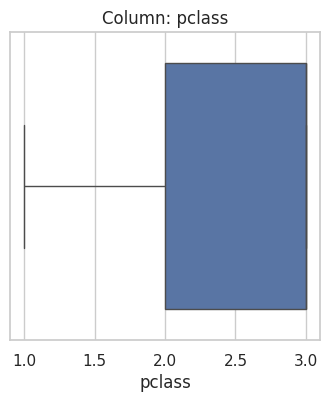

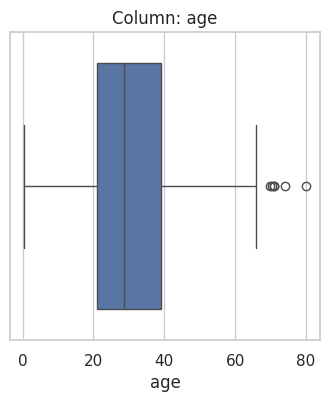

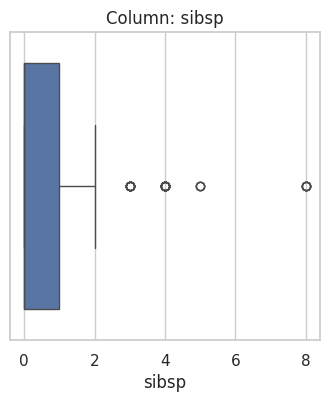

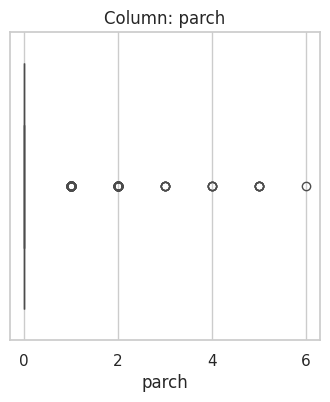

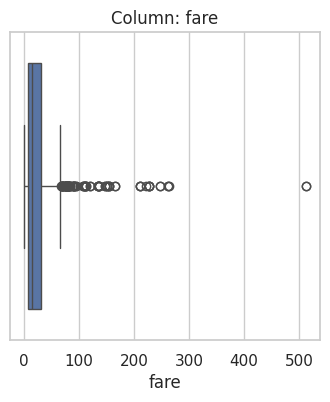

In [ ]:
for col in num_columns:
  plt.figure(figsize=(4,4))
  sns.boxplot(x = X_train[col])
  plt.title(f"Column: {col}")
  plt.show()

In [ ]:
def iqr(series):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  return lower, upper

def compute_train_bounds(df, cols):
  bounds = {}
  for col in cols:
    low, high = iqr(df[col])
    bounds[col] = (low, high)
  return bounds

In [ ]:
# apply the same bounds to any set train or test

def cap_outliers_with_bounds(df, bounds):
  df_capped = df.copy()
  for col, (low, high) in bounds.items():
    df_capped[col] = np.where(df_capped[col] < low, low, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > high, high, df_capped[col])
  return df_capped

In [ ]:
valid_outliers_column = ['age', 'fare']
train_bounds = compute_train_bounds(X_train_enc, valid_outliers_column)
print(train_bounds)

{'age': (np.float64(-6.0), np.float64(66.0)), 'fare': (np.float64(-26.7605), np.float64(65.6563))}


In [ ]:
# apply capping both training and test data with TRAIN bounds
X_train_capped  = cap_outliers_with_bounds(X_train_enc, train_bounds)
X_test_capped  = cap_outliers_with_bounds(X_test_enc, train_bounds)